# Machine Learning for Single-Cell Biology
***

Winter Semester 2024/25<br />
Manfred Claassen, Matthias Bruhns, Jan Schleicher
<br />
***

## Assignment 3

### By Ieva Kerseviciute and Arne Gittel


In [41]:
import numpy as np
import pandas as pd
import umap
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import FactorAnalysis
import os
from matplotlib import pyplot as plt
import seaborn as sns

from typing import List, Union, Tuple

import gseapy as gp


sns.set_style("ticks")
%matplotlib inline

In [42]:
DATA_PATH = r"C:\Users\Arne.Gittel\Documents\Neuro Master\Machine learning for single cell biology\assignments\3\data"
OUTPUT_PATH = r"C:\Users\Arne.Gittel\Documents\Neuro Master\Machine learning for single cell biology\assignments\3"
os.makedirs(OUTPUT_PATH, exist_ok=True)

### Task 1

For this task, you have been provided with the following expression dataset and cell type
annotations. The dataset was normalized such that each cell had the same total expression.
Subsequently, each entry of the normalized expression matrix was transformed like so:
log(count+1).

Expression data: 
expression_data_1.txt

Cell type labels: 
celltype_data_1.txt

A. Plot a heatmap of mean gene expression per cell type of the following genes: (10 P)
CCR7, CD14, IL7R, S100A4, MS4A1, CD8A, FCGR3A, MS4A7, FCGR3A, NKG7,
FCER1A, PPBP

B. Based on the heatmap (Task 1A) identify one gene per cell type that could serve as a
cell type marker. Explain your reasoning. (10 P)

C. Project the expression data into 2D using UMAP and plot each marker on the projection. (10 P)

In [43]:
def task1a_get_mean_per_cell_type(expression_df: pd.DataFrame,
                                  cell_type_df: pd.DataFrame,
                                  gene_list: List[str],
                                  cell_type_col: str = "cell_type") -> pd.DataFrame:
    """
    Compute the mean expression per cell type from a single-cell expression matrix.
    :param expression_df: A DataFrame of shape (n_cells, n_genes) containing the expression data.
    :param cell_type_df: A DataFrame of shape (n_cells, n_annotations) containing metadata (including cell type).
    :param gene_list: A list of marker genes for which to compute mean expression.
    :param cell_type_col: The name of the column in cell_type_df that contains cell type annotations.
    :return: A DataFrame of shape (n_cell_types, n_markers) with the mean expression per cell type for the given genes.
    """
    # cell_type_means = pd.DataFrame(index=cell_type_df[cell_type_col].astype("category").cat.categories,
    #                                columns=gene_list)
    #########################
    # INSERT YOUR CODE HERE #
    #########################

    # Filter expression_df to only include genes in the gene_list
    filtered_expression_df = expression_df[gene_list]

    # Add cell type information to the expression data
    expression_with_cell_type = pd.concat([cell_type_df[cell_type_col], filtered_expression_df], axis=1)

    # Ensure that only numeric columns are used for the mean calculation
    numeric_columns = expression_with_cell_type.select_dtypes(include='number').columns

    # Group by the cell type column and calculate the mean expression for each gene (numeric columns only)
    cell_type_means = expression_with_cell_type.groupby(cell_type_df[cell_type_col])[numeric_columns].mean()


    return cell_type_means

In [44]:
def task1a_plot_heatmap(cell_type_means: pd.DataFrame) -> None:
    """
    Plot a heatmap displaying mean expression per cell type.
    :param cell_type_means: A DataFrame of shape (n_cell_types, n_markers) with the mean expression per cell type.
    :return:
    """
    #########################
    # INSERT YOUR CODE HERE #
    #########################

    #plot heatmap
    plt.figure(figsize=(10, 10))
    sns.heatmap(cell_type_means, cmap="viridis", cbar_kws={'label': 'Mean expression'})
    plt.xlabel("Marker genes")
    plt.ylabel("Cell types")
    plt.title("Mean expression per cell type")
    plt.tight_layout()
    
    return None

In [45]:
def task1c_compute_umap(expression_df: pd.DataFrame) -> np.ndarray:
    """
    Compute a UMAP embedding of the expression data.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :return: An array of shape (n_cells, 2) containing the embedding coordinates.
    """
    embedding = np.zeros((expression_df.shape[0], 2))
    #########################
    # INSERT YOUR CODE HERE #
    #########################

    # Compute UMAP embedding
    reducer = umap.UMAP(n_components=2)
    embedding = reducer.fit_transform(expression_df)

    return embedding

In [46]:
# Load data
expression_data = pd.read_csv(os.path.join(DATA_PATH, "expression_data_1.txt"), sep="\t", index_col=0)
cell_type_data = pd.read_csv(os.path.join(DATA_PATH, "cell_type_data_1.txt"), sep="\t", index_col=0)

In [47]:
expression_data.shape

(6112, 3001)

In [48]:
cell_type_data.shape

(6112, 1)

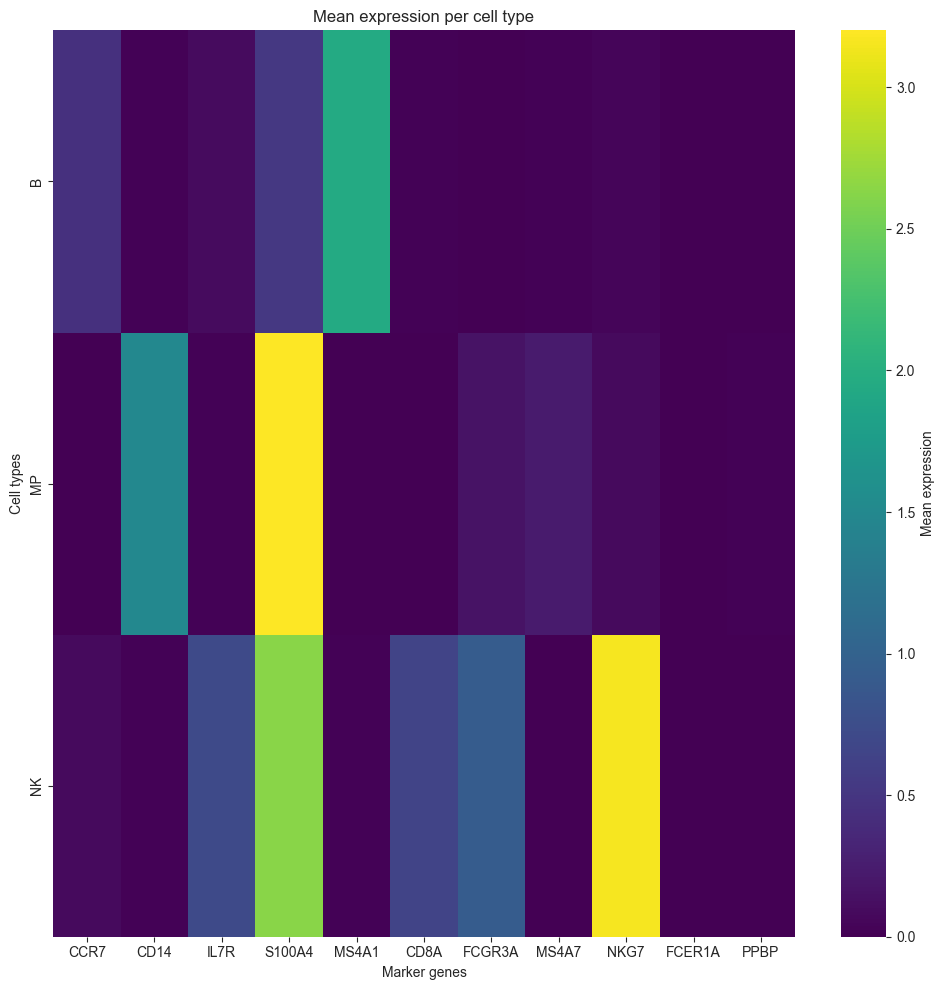

In [49]:
# Get mean expression of marker genes per cell type
marker_genes = ["CCR7", "CD14", "IL7R", "S100A4", "MS4A1", "CD8A", "FCGR3A", "MS4A7", "NKG7", "FCER1A", "PPBP"]
mean_expression = task1a_get_mean_per_cell_type(expression_df=expression_data,
                                                cell_type_df=cell_type_data,
                                                gene_list=marker_genes)

task1a_plot_heatmap(mean_expression)

In [50]:
mean_expression

,CCR7,CD14,IL7R,S100A4,MS4A1,CD8A,FCGR3A,MS4A7,NKG7,FCER1A,PPBP
cell_type,,,,,,,,,,,
B,0.450050,0.013957,0.087897,0.521108,1.944864,0.019383,0.010428,0.024018,0.040478,0.000000,0.003125
MP,0.001695,1.488222,0.014098,3.201191,0.004345,0.003538,0.155906,0.225230,0.075358,0.001059,0.023283
NK,0.086120,0.014691,0.714987,2.638310,0.024411,0.648337,0.917810,0.001588,3.152994,0.001931,0.002862


**Provide your text answers for Task 1B here**

Marker genes should have a unique expression pattern therefore:

For cell type B: MS4A1 is a good marker gene 

For cell type MP: CD14 is good marker gene

For cell type NK: NKG7 is a good marker gene 

In [51]:
# Compute UMAP
umap_coords = task1c_compute_umap(expression_df=expression_data)

c:\Users\Arne.Gittel\AppData\Local\anaconda3\envs\MLSC\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


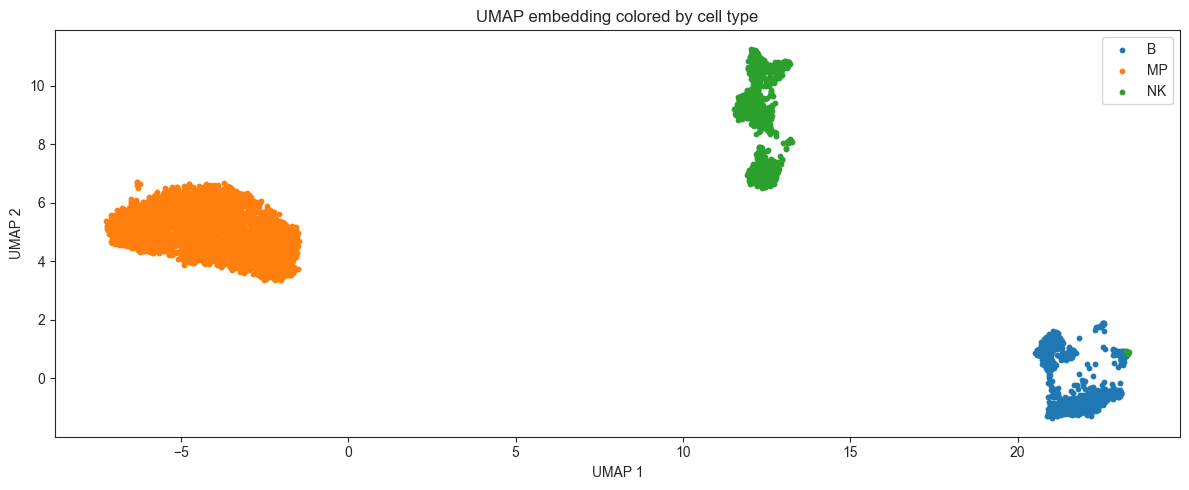

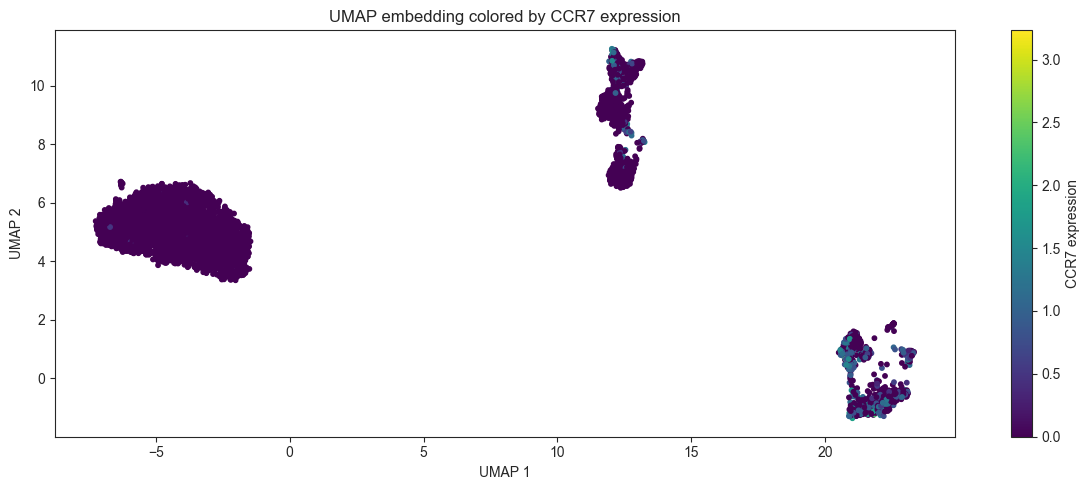

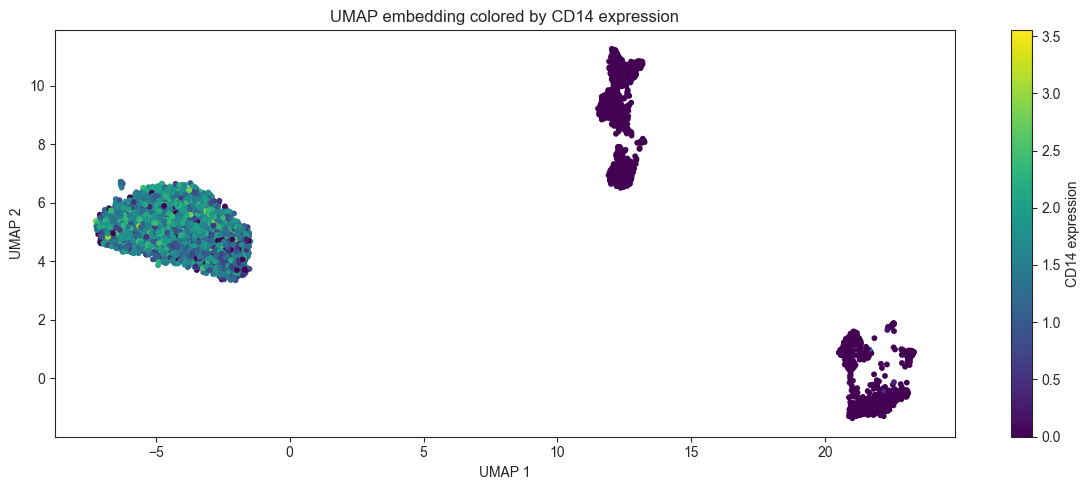

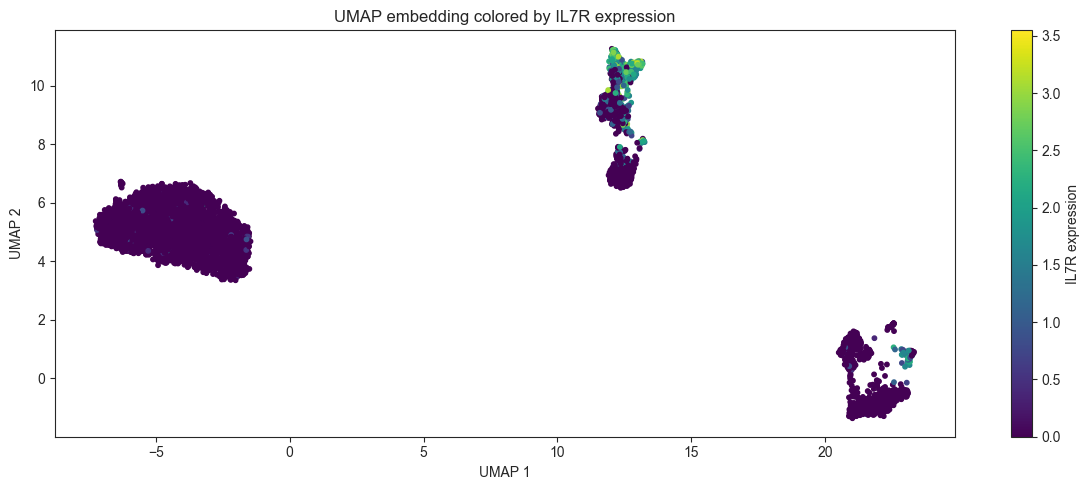

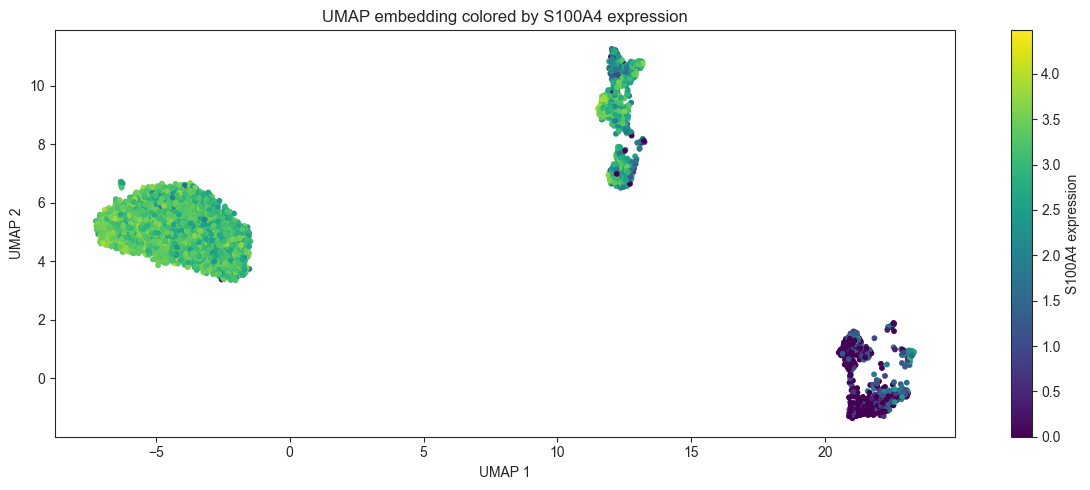

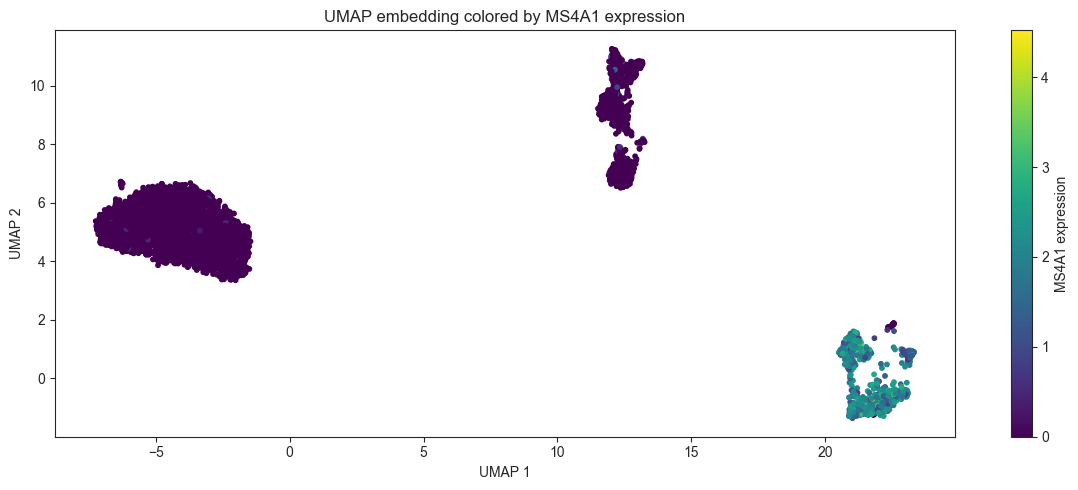

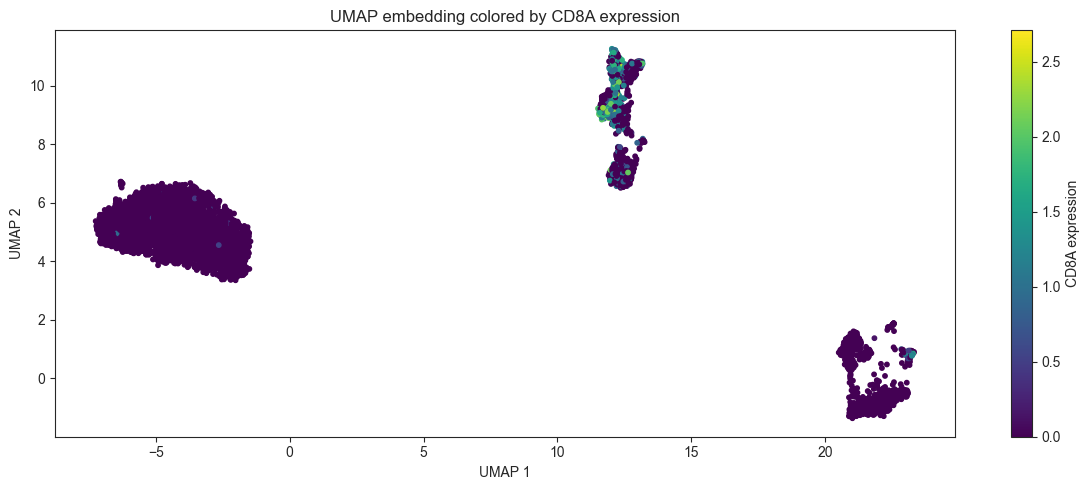

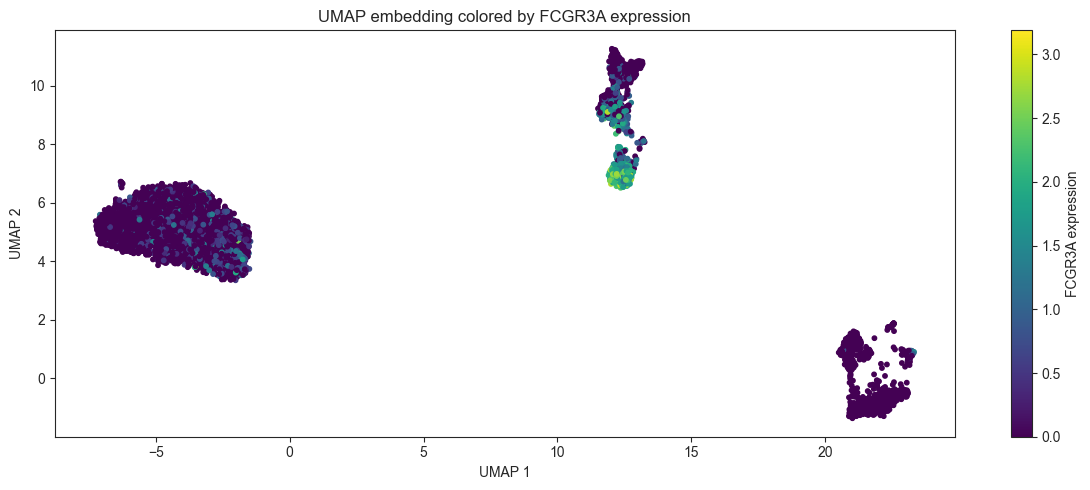

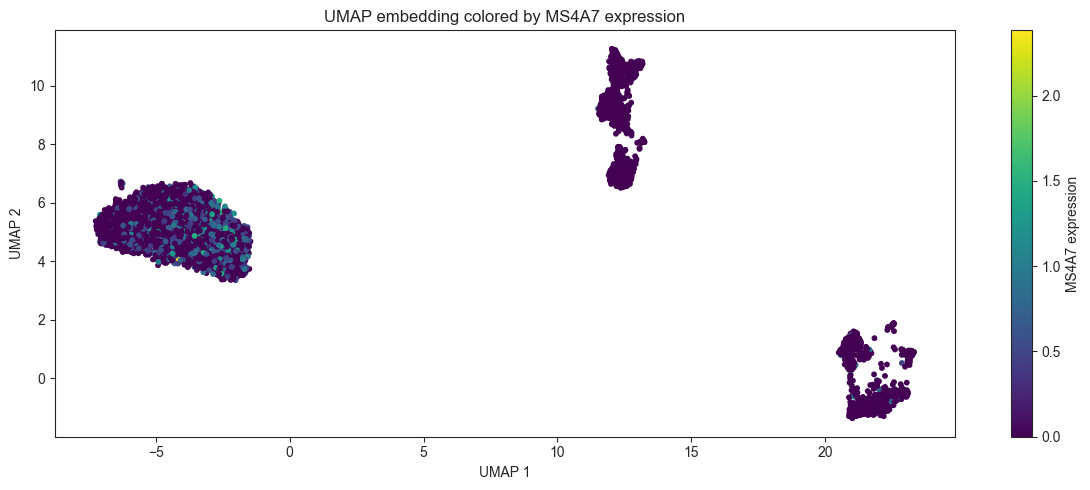

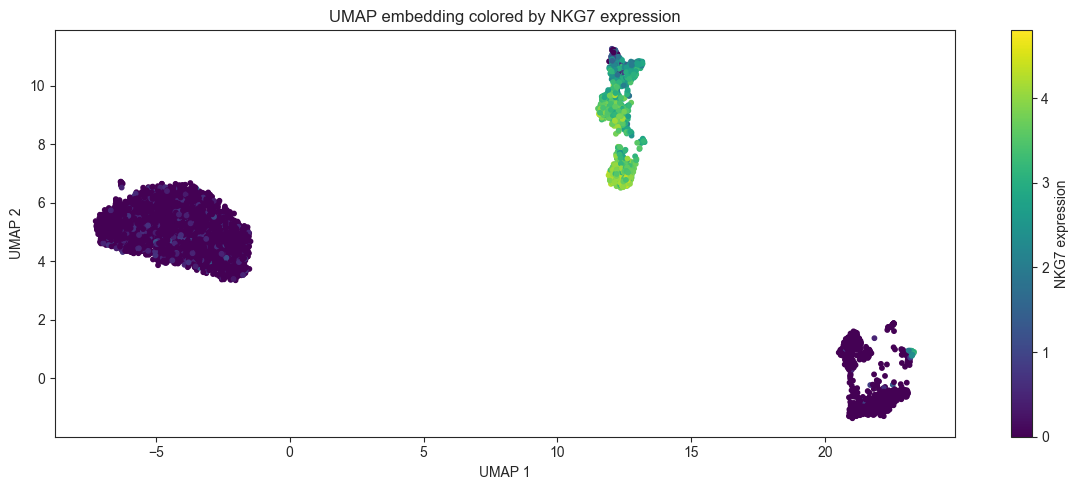

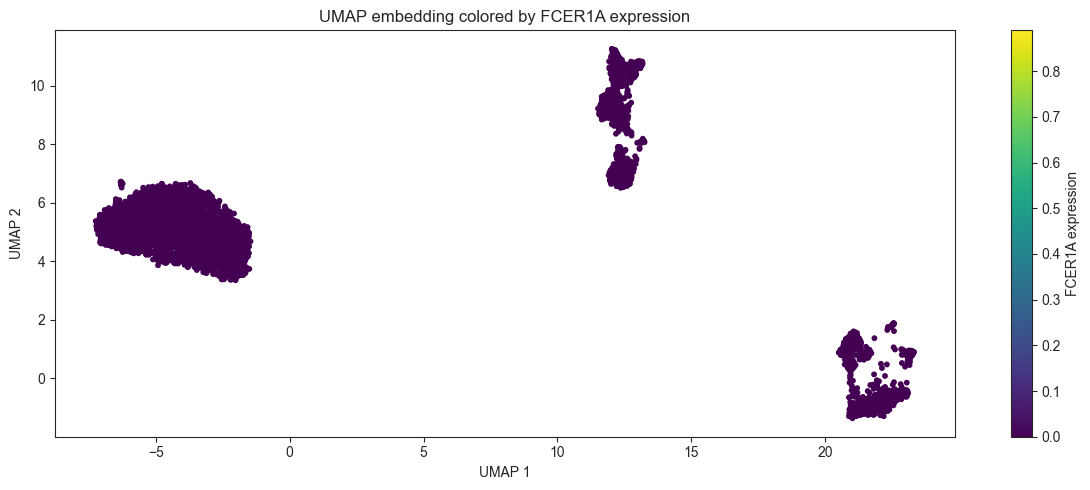

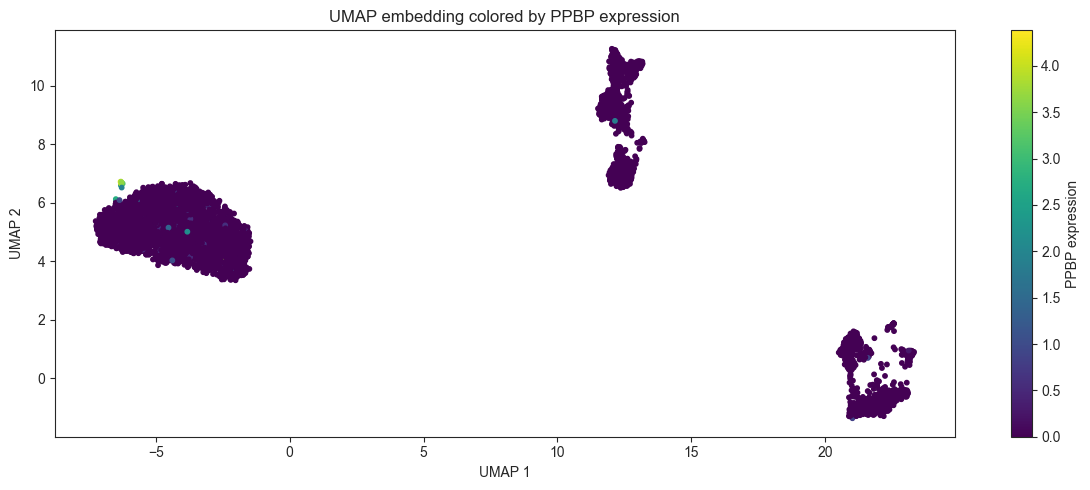

In [52]:
# Plot UMAPs with gene expression
#########################
# INSERT YOUR CODE HERE #
#########################

def plot_UMAP (embedding, cell_type_df, cell_type_col="cell_type", title="UMAP embedding colored by cell type"):
    plt.figure(figsize=(12, 5))
    
    for cell_type in cell_type_df[cell_type_col].unique():
        mask = cell_type_df[cell_type_col] == cell_type
        plt.scatter(embedding[mask, 0], embedding[mask, 1], label=cell_type, s=10)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    return None

def plot_UMAP_expression (embedding, gene_expression_df, gene):
    plt.figure(figsize=(12, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=gene_expression_df[gene], cmap="viridis", s=10)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(f"UMAP embedding colored by {gene} expression")
    plt.colorbar(label=f"{gene} expression")
    plt.tight_layout()

    return None



plot_UMAP(umap_coords, cell_type_data)

for marker_gene in marker_genes:
    plot_UMAP_expression(umap_coords, expression_data, marker_gene)


### Task 2

For this task, use the expression data and cell type labels from Task 1.


A. For each cell type and each gene perform differential expression testing using the Mann-
Whitney U test. Use the provided python function. (10 P)


B. Based on the list of differentially expressed genes per cell type, what biological functions
can you infer for each cell type? Briefly explain your reasoning/methodology. (15 P)

In [53]:
def task2a_differential_expression_testing(expression_df: pd.DataFrame,
                                           cell_type_df: pd.DataFrame,
                                           cell_type_col: str = "cell_type") -> pd.DataFrame:
    """
    Perform a differential expression analysis between cell types.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :param cell_type_df: A DataFrame of shape (n_cells, n_annotations) containing metadata (including cell type).
    :param cell_type_col: The name of the column in cell_type_df that contains cell type annotations.
    :return: A DataFrame with the results of differential expression testing.
    """
    de_results = pd.DataFrame(columns=pd.MultiIndex.from_product([cell_type_df[cell_type_col].unique(),
                                                                  ["p", "logFC", "p_adj"]]),
                              index=expression_df.columns)
    # stats.mannwhitneyu
    #########################
    # INSERT YOUR CODE HERE #
    #########################

    # Perform differential expression testing
    for gene in expression_df.columns:
        for cell_type in cell_type_df[cell_type_col].unique():
            # Perform Mann-Whitney U test
            group1 = expression_df.loc[cell_type_df[cell_type_col] == cell_type, gene]
            group2 = expression_df.loc[cell_type_df[cell_type_col] != cell_type, gene]
            p = stats.mannwhitneyu(group1, group2).pvalue
            logFC = np.log2(group1.mean() + 1) - np.log2(group2.mean() + 1)
            de_results.loc[gene, (cell_type, "p")] = p
            de_results.loc[gene, (cell_type, "logFC")] = logFC

    # correct for multiple testing using the Benjamini-Hochberg procedure
    p_values = de_results.xs("p", axis=1, level=1)
    _, p_values_adj, _, _ = multipletests(p_values.values.flatten(), method="fdr_bh")
    de_results.loc[:, pd.IndexSlice[:, "p_adj"]] = p_values_adj.reshape(p_values.shape)
    
    return de_results

In [54]:
# Perform differential expression analysis
de_genes = task2a_differential_expression_testing(expression_df=expression_data,
                                                  cell_type_df=cell_type_data)
de_genes.to_csv(os.path.join(OUTPUT_PATH, "de_results.tsv"), sep="\t")



In [55]:
de_genes

B                            MP                      \
                   p     logFC     p_adj         p     logFC     p_adj   
AC145212.1  0.018745  0.007336   0.04441  0.026916 -0.007676  0.062648   
AC233755.2  0.037003  0.001092  0.079319  0.225238 -0.000504  0.356884   
HES4             0.0 -0.034716       0.0       0.0  0.032154       0.0   
TNFRSF18    0.020036 -0.031179  0.047344       0.0 -0.115234       0.0   
TNFRSF4     0.053422 -0.013518  0.111956       0.0 -0.042862       0.0   
...              ...       ...       ...       ...       ...       ...   
CD40LG      0.044804 -0.019955  0.095068       0.0 -0.062108       0.0   
FMR1-IT1    0.759862  -0.00041  0.887179   0.47667  0.000437  0.646401   
BX546450.2       1.0       0.0       1.0       1.0       0.0       1.0   
PLXNA3           0.0  0.027854       0.0       0.0 -0.032727       0.0   
AC009494.2  0.631987  -0.00027  0.756016  0.225238 -0.000543  0.356884   

                  NK                      
                   p     logFC     p_adj  
AC145212.1  0.680761  0.004304  0.807177  
AC233755.2  0.598031 -0.000261  0.749662  
HES4        0.000011 -0.014685  0.000039  
TNFRSF18         0.0  0.185069       0.0  
TNFRSF4          0.0  0.071797       0.0  
...              ...       ...       ...  
CD40LG           0.0  0.103798       0.0  
FMR1-IT1    0.577162 -0.000253  0.749662  
BX546450.2       1.0       0.0       1.0  
PLXNA3      0.001078  0.021298  0.003098  
AC009494.2   0.05811  0.001008  0.116387  

[3001 rows x 9 columns]

C:\Users\Arne.Gittel\AppData\Local\Temp\ipykernel_5100\131053350.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cell_type_data['p_adj'] = pd.to_numeric(cell_type_data['p_adj'], errors='coerce')
C:\Users\Arne.Gittel\AppData\Local\Temp\ipykernel_5100\131053350.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cell_type_data['logFC'] = pd.to_numeric(cell_type_data['logFC'], errors='coerce')


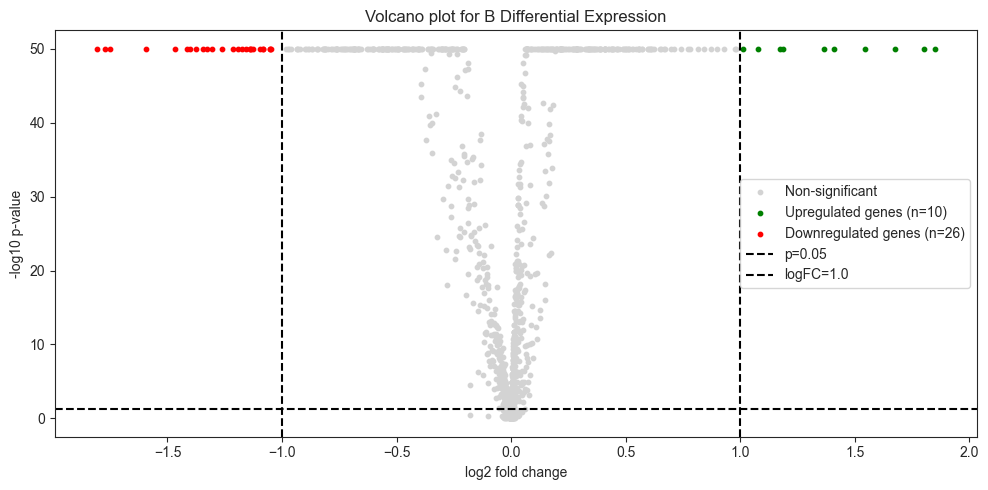

Significant upregulated genes for cell type B:
Index(['RALGPS2', 'MS4A1', 'IGHD', 'IGHM', 'CD79B', 'CD79A', 'IGKC', 'IGLC2',
       'BANK1', 'LTB'],
      dtype='object')


Significant downregulated genes for cell type B:
Index(['S100A11', 'S100A12', 'S100A8', 'S100A4', 'S100A9', 'MNDA', 'PSAP',
       'SRGN', 'NEAT1', 'AC020656.1', 'DUSP6', 'LYZ', 'SERPINA1', 'FOS',
       'TYROBP', 'TYMP', 'LGALS1', 'CSTA', 'CD14', 'DUSP1', 'VCAN', 'LST1',
       'AIF1', 'FGL2', 'CEBPD', 'ANXA1'],
      dtype='object')


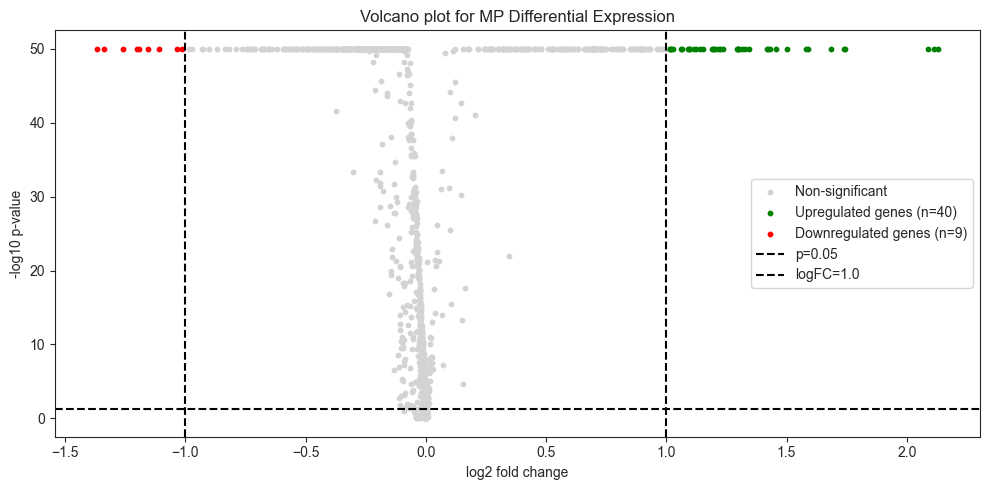

Significant upregulated genes for cell type MP:
Index(['CTSS', 'S100A12', 'S100A8', 'NCF2', 'S100A9', 'MNDA', 'RGS2', 'PSAP',
       'MPEG1', 'MS4A6A', 'JAML', 'AC020656.1', 'DUSP6', 'LYZ', 'KCTD12',
       'TNFSF13B', 'SERPINA1', 'FOS', 'COTL1', 'GRN', 'TYROBP', 'CFD', 'IFI30',
       'TYMP', 'TNFSF10', 'CSTA', 'CD14', 'DUSP1', 'VCAN', 'LST1', 'AIF1',
       'CPVL', 'FGL2', 'TMEM176B', 'CD36', 'CEBPD', 'FCN1', 'AP1S2', 'SAT1',
       'CYBB'],
      dtype='object')


Significant downregulated genes for cell type MP:
Index(['IGHM', 'CCL5', 'NKG7', 'CD79A', 'IGKC', 'GNLY', 'CST7', 'GZMA', 'LTB'], dtype='object')


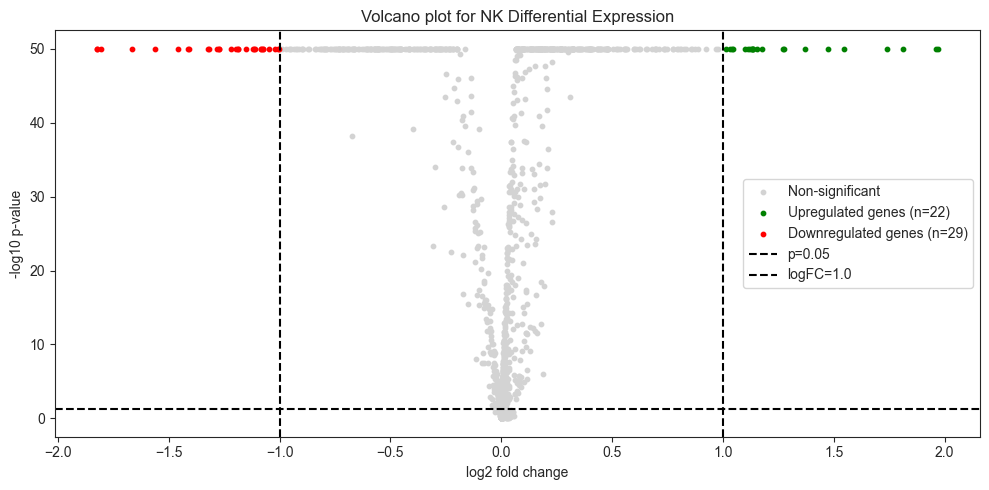

Significant upregulated genes for cell type NK:
Index(['CD247', 'CD2', 'PRF1', 'CD3D', 'CTSW', 'CD3E', 'CD3G', 'KLRB1',
       'KLRD1', 'GZMH', 'GZMB', 'CCL5', 'CD7', 'CCL4', 'NKG7', 'GZMM', 'ARL4C',
       'GNLY', 'CST7', 'FGFBP2', 'HOPX', 'GZMA'],
      dtype='object')


Significant downregulated genes for cell type NK:
Index(['CTSS', 'S100A12', 'S100A8', 'NCF2', 'S100A9', 'MNDA', 'PSAP', 'MPEG1',
       'AC020656.1', 'DUSP6', 'LYZ', 'TNFSF13B', 'SERPINA1', 'FOS', 'GRN',
       'IFI30', 'TYMP', 'CSTA', 'CD14', 'CD74', 'DUSP1', 'VCAN', 'HLA-DRB1',
       'LST1', 'AIF1', 'HLA-DRA', 'MARCKS', 'FGL2', 'CYBB'],
      dtype='object')


In [56]:
def vulcano_plot(de_results: pd.DataFrame, cell_type: str, alpha: float = 0.05, logFC_threshold: float = 1.0) -> None:
    """
    Plot a volcano plot of the differential expression analysis results.
    :param de_results: A DataFrame with the results of differential expression testing.
    :param cell_type: The cell type for which to plot the volcano plot.
    :param alpha: The significance threshold for p-values.
    :param logFC_threshold: The threshold for log-fold change.
    :return:
    """

    # Check if the 'cell_type' exists in the columns
    if cell_type not in de_results.columns.levels[0]:
        print(f"Cell type '{cell_type}' not found in the DataFrame columns.")
        return None

    # Get the data for the specified cell type
    cell_type_data = de_results[cell_type]
    
    # # Print the min and max of p_adj and logFC
    # min_p_adj = cell_type_data['p_adj'].min()
    # max_p_adj = cell_type_data['p_adj'].max()
    # min_logFC = cell_type_data['logFC'].min()
    # max_logFC = cell_type_data['logFC'].max()
    # print(f"Min p_adj: {min_p_adj}")
    # print(f"Max p_adj: {max_p_adj}")
    # print(f"Min logFC: {min_logFC}")
    # print(f"Max logFC: {max_logFC}")


    # Mask for upregulated genes: p_adj < alpha and logFC > logFC_threshold
    upregulated_mask = (cell_type_data['p_adj'] < alpha) & (cell_type_data['logFC'] > logFC_threshold)
    
    # Mask for downregulated genes: p_adj < alpha and logFC < -logFC_threshold
    downregulated_mask = (cell_type_data['p_adj'] < alpha) & (cell_type_data['logFC'] < -logFC_threshold)
    
    # Combine both masks for significant results
    mask = upregulated_mask | downregulated_mask


    # Ensure 'p_adj' column is numeric
    cell_type_data['p_adj'] = pd.to_numeric(cell_type_data['p_adj'], errors='coerce')
    cell_type_data['logFC'] = pd.to_numeric(cell_type_data['logFC'], errors='coerce')

    # Prepare plot
    plt.figure(figsize=(10, 5))

    # # Scatter plot for significant and non-significant points
    # plt.scatter(cell_type_data['logFC'], 
    #             -np.log10(cell_type_data['p_adj'] + 1e-10),  # Apply log10 transformation with a small offset
    #             c=mask, cmap='coolwarm', label=f"{cell_type} (n={mask.sum()})", s=10)

    # Scatter plot for significant and non-significant points
    plt.scatter(cell_type_data['logFC'][~mask], 
                -np.log10(cell_type_data['p_adj'][~mask] + 1e-50),  # Apply log10 transformation with a small offset
                c='lightgrey', label="Non-significant", s=10)
    plt.scatter(cell_type_data['logFC'][upregulated_mask],
                -np.log10(cell_type_data['p_adj'][upregulated_mask] + 1e-50),  # Apply log10 transformation with a small offset
                c='green', label=f"Upregulated genes (n={upregulated_mask.sum()})", s=10)   
    plt.scatter(cell_type_data['logFC'][downregulated_mask],
                -np.log10(cell_type_data['p_adj'][downregulated_mask] + 1e-50),  # Apply log10 transformation with a small offset
                c='red', label=f"Downregulated genes (n={downregulated_mask.sum()})", s=10)
                
    
    # Plot the threshold lines
    plt.axhline(-np.log10(alpha), color="black", linestyle="--", label=f"p={alpha}")
    plt.axvline(logFC_threshold, color="black", linestyle="--", label=f"logFC={logFC_threshold}")
    plt.axvline(-logFC_threshold, color="black", linestyle="--")

    # Labeling the plot
    plt.xlabel("log2 fold change")
    plt.ylabel("-log10 p-value")
    plt.title(f"Volcano plot for {cell_type} Differential Expression")
    plt.legend()
    plt.tight_layout()

    # Show plot
    plt.show()

    #print gen names of significant upregulated genes
    print(f"Significant upregulated genes for cell type {cell_type}:")
    print(cell_type_data[upregulated_mask].index)
    print("\n")
    #print gen names of significant downregulated genes
    print(f"Significant downregulated genes for cell type {cell_type}:")
    print(cell_type_data[downregulated_mask].index)


    def index_to_list(index):
        return list(index)

    upregulated_genes = index_to_list(cell_type_data[upregulated_mask].index)
    downregulated_genes = index_to_list(cell_type_data[downregulated_mask].index)

    # Return the significant upregulated and downregulated gene lists
    return upregulated_genes, downregulated_genes


upregulated_genes_B, downregulated_genes_B = vulcano_plot(de_genes, "B")

upregulated_genes_MP, downregulated_genes_MP = vulcano_plot(de_genes, "MP")

upregulated_genes_NK, downregulated_genes_NK = vulcano_plot(de_genes, "NK")




In [57]:
def perform_enrichment_analysis(gene_list, cell_type, enrichr_library='KEGG_2016', pval_cutoff=0.05):
    """
    Perform enrichment analysis for upregulated and downregulated genes for a specific cell type.
    
    Parameters:
        gene_list (dict): Dictionary with 'upregulated' and 'downregulated' gene lists.
        cell_type (str): Name of the cell type being analyzed.
        enrichr_library (str): The Enrichr library to use for enrichment analysis.
        pval_cutoff (float): Adjusted p-value cutoff for filtering significant results.
    
    Returns:
        None: Prints significant results to the console.
    """
    print(f"\n{cell_type} Cells")

    for direction, genes in gene_list.items():
        if not genes:
            print(f"No {direction} genes provided for {cell_type}.")
            continue

        outdir = f'{direction}_enrichment_{cell_type}'
        enrich_results = gp.enrichr(
            gene_list=genes,
            gene_sets=enrichr_library,
            outdir=outdir,
            cutoff=pval_cutoff
        )

        significant_results = enrich_results.results[enrich_results.results['Adjusted P-value'] < pval_cutoff]
        print(f"\n{direction.capitalize()} genes enrichment for {cell_type}:")
        if not significant_results.empty:
            print(significant_results[['Term', 'Adjusted P-value', 'Overlap']])
        else:
            print(f"No significant {direction} enrichment found.")

# Define upregulated and downregulated gene lists for each cell type
b_cell_genes = {
    'upregulated': upregulated_genes_B,
    'downregulated': downregulated_genes_B
}

mp_cell_genes = {
    'upregulated': upregulated_genes_MP,
    'downregulated': downregulated_genes_MP
}

nk_cell_genes = {
    'upregulated': upregulated_genes_NK,
    'downregulated': downregulated_genes_NK
}

enrichr_library = 'GO_Biological_Process_2021, GO_Molecular_Function_2021, GO_Cellular_Component_2021' # 'KEGG_2016', 'Reactome_2016'
# Perform analysis for each cell type
perform_enrichment_analysis(b_cell_genes, 'B', enrichr_library)
perform_enrichment_analysis(mp_cell_genes, 'MP', enrichr_library)
perform_enrichment_analysis(nk_cell_genes, 'NK', enrichr_library)



B Cells

Upregulated genes enrichment for B:
                                                 Term  Adjusted P-value  \
0                      B cell activation (GO:0042113)          0.000002   
1      B cell receptor signaling pathway (GO:0050853)          0.000008   
2                 B cell differentiation (GO:0030183)          0.000031   
3             lymphocyte differentiation (GO:0030098)          0.000061   
4   antigen receptor-mediated signaling pathway (G...          0.000517   
5                   B cell proliferation (GO:0042100)          0.000535   
6               lymphocyte proliferation (GO:0046651)          0.000649   
7           store-operated calcium entry (GO:0002115)          0.014477   
8        calcium ion import into cytosol (GO:1902656)          0.024090   
9     calcium ion transport into cytosol (GO:0060402)          0.026458   
10  negative regulation of lymphocyte activation (...          0.026458   
11  negative regulation of B cell activation (GO:0... 

**Provide your text answers for Task 2B here**

With a volcano plot we searched for genes that had a significant (adjusted p after multiple testing correction < 0.05) up or down regulation (at least 2 fold) in one cell type compared to the other cell types. These genes were then analysed via gene set enrichment analysis based on GO_Biological_Process_2021, GO_Molecular_Function_2021, GO_Cellular_Component_2021 libraries. 

As expected the upregulated genes for all clusters are involved in imune response pathways:

B Cells:

Upregulated Functions: B cells are primarily involved in activation, differentiation, and proliferation (e.g., B cell activation, receptor signaling, and antigen receptor-mediated signaling). They play a crucial role in immune responses by producing antibodies and undergoing processes like lymphocyte differentiation. The upregulation of genes related to calcium ion transport suggests that calcium signaling is vital in regulating B cell function.

Downregulated Functions: In contrast, genes downregulated in B cells are related to neutrophil-mediated immunity and inflammatory responses, reflecting their specialized role in the adaptive immune system rather than in the inflammatory responses driven by neutrophils.

MP (Macrophage) Cells:

Upregulated Functions: Macrophages are essential in immune responses, particularly neutrophil degranulation, inflammatory responses, and pattern recognition receptor signaling. The genes upregulated in MP cells support their role in phagocytosis and immune defense against pathogens. They are also involved in the formation of granules and membranes of organelles, which aids in their immune functions.

Downregulated Functions: Macrophages show downregulation of genes involved in T cell apoptosis regulation and cell-cell adhesion, which may suggest their role in modulating immune responses and preventing excessive inflammation or tissue damage during infection or injury.

NK (Natural Killer) Cells:

Upregulated Functions: NK cells are involved in immune surveillance and activation, particularly through T cell selection and regulation of immune responses. They are critical in targeting and eliminating infected or tumor cells through mechanisms like apoptosis induction and chemotaxis. The upregulated genes related to granules and lytic vacuoles suggest their key role in releasing cytotoxic molecules to destroy target cells.

Downregulated Functions: The downregulation of genes in NK cells related to neutrophil degranulation and inflammatory response indicates their specific function in the innate immune system, with a focus on immune surveillance rather than inflammatory responses driven by neutrophils.




### Task 3

For this task, use the expression data and cell type labels from Task 1.
Use the code provided to perform factor analysis with 3 factors.


A. Plot the factor activity for each factor on the 2D UMAP generated in Task 1C. What
can you infer about the relationship between the cell types and factors based on these
plots? (10 P)


B. Extract the gene loadings on each factor and perform gene set enrichment analysis.
What inference can you make about the cell types based on this analysis? (35 P)

In [58]:
def task3a_factor_analysis(expression_df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    """
    Perform factor analysis on the expression data.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :return: An array with factor activities of shape (n_cells, n_factors) and
    an array with gene loadings of shape (n_factors, n_genes).
    """
    # fa = FactorAnalysis(n_components=3)

    factor_activity = np.zeros((expression_df.shape[0], 3))
    gene_loadings = np.zeros((3, expression_df.shape[1]))
    print(gene_loadings.shape)
    #########################
    # INSERT YOUR CODE HERE #
    #########################

    # Perform factor analysis
    fa = FactorAnalysis(n_components=3)
    fa.fit(expression_df)
    factor_activity = fa.transform(expression_df)
    gene_loadings = fa.components_  # gene loadings
    print(gene_loadings.shape)


    return factor_activity, gene_loadings

In [59]:
# Run factor analysis
factor_activities, gene_loadings = task3a_factor_analysis(expression_df=expression_data)

(3, 3001)
(3, 3001)


Min factor activity: -0.012792175203771492
Max factor activity: 78.17288522834414
Min factor activity: -1.12653927002117
Max factor activity: 1.653843647830325
Min factor activity: -2.2529262619939665
Max factor activity: 2.288717603733581


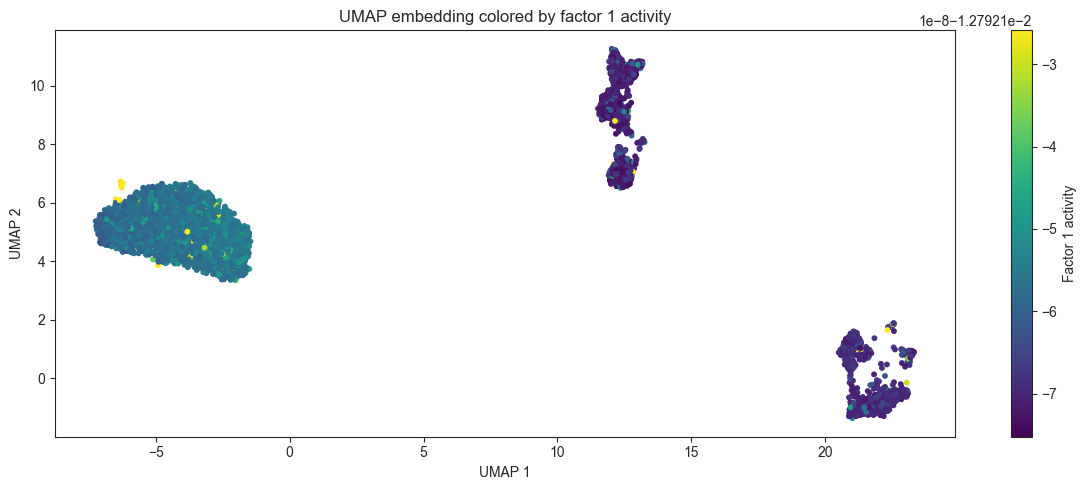

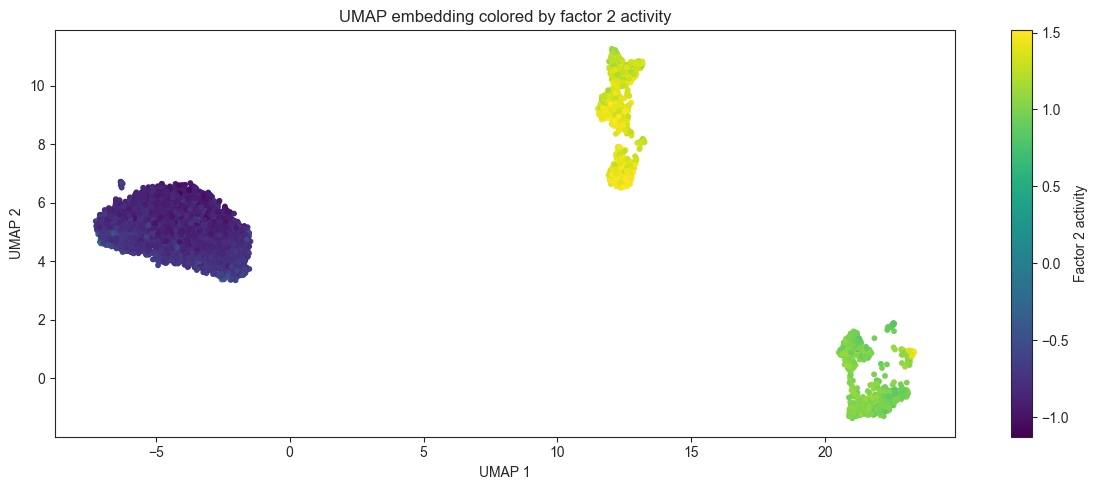

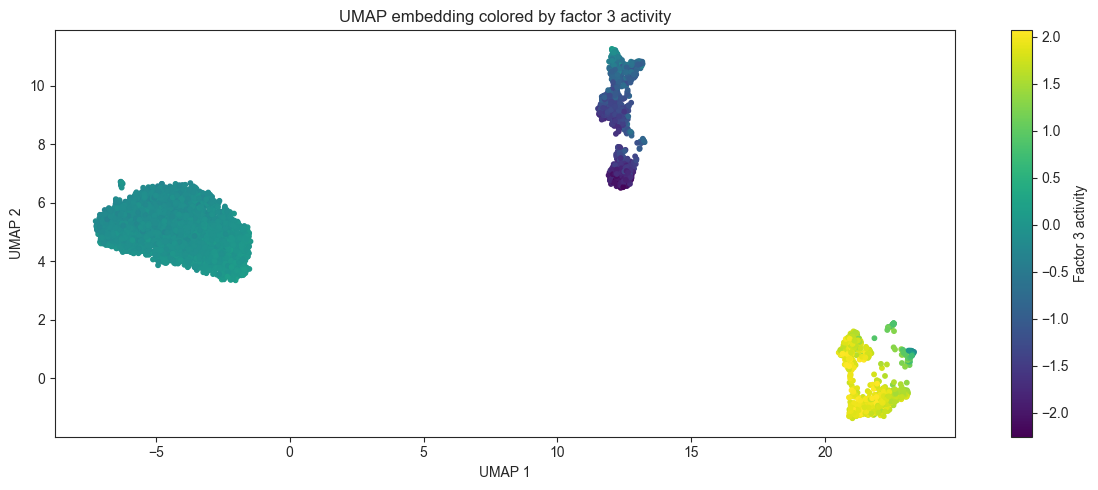

In [60]:
# Plot factor activity on UMAP (you can use the function from Task 1C)
#########################
# INSERT YOUR CODE HERE #
#########################
def plot_UMAP_FAexpression(embedding, factor_activity, factor):
    """
    Plot the UMAP embedding colored by the activity of a specific factor.
    :param embedding: Array of shape (n_cells, 2) with UMAP coordinates.
    :param factor_activity: Array of shape (n_cells, n_factors) with factor activities.
    :param factor: Index of the factor to use for coloring (integer).
    """
    plt.figure(figsize=(12, 5))
    # plt.scatter(embedding[:, 0], embedding[:, 1], c=factor_activity[:, factor], cmap="viridis", s=10)
    # print min and max values of factor activity
    print(f"Min factor activity: {factor_activity[:, factor].min()}")
    print(f"Max factor activity: {factor_activity[:, factor].max()}")
    
    vmax_value = np.percentile(factor_activity[:, factor], 99)  # 99th percentile to ignore extreme outliers
    plt.scatter(embedding[:, 0], embedding[:, 1], c=factor_activity[:, factor], cmap="viridis", s=10, vmax=vmax_value)

    # log_factor_activity = np.log1p(factor_activity[:, factor])  # log1p(x) = log(1 + x), handles small/zero values
    # plt.scatter(embedding[:, 0], embedding[:, 1], c=log_factor_activity, cmap="viridis", s=10)

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(f"UMAP embedding colored by factor {factor + 1} activity")
    plt.colorbar(label=f"Factor {factor + 1} activity")
    plt.tight_layout()

    return None

# Loop through each factor and plot its activity
for factor in range(factor_activities.shape[1]):
    plot_UMAP_FAexpression(umap_coords, factor_activities, factor)

**Provide your text answers for Task 3A here**

Factor 1: To address the impact of outliers on visual interpretation, the heatmap for Factor 1 was capped at the 99th percentile. The B cell cluster in the UMAP exhibits elevated factor activity, whereas the other two clusters display generally lower activity, with only a few isolated samples showing elevated values.

Factor 2: Factor 2 demonstrates the highest activity in the NK cell cluster, moderate activity in the MP cell cluster, and low activity in the B cell cluster. Activity levels appear relatively homogeneous within each cluster.

Factor 3: Factor 3 exhibits the highest activity in the MP cell cluster, with notable but heterogeneous activity in the NK cell cluster. This heterogeneity correlates with intracluster gene activity patterns, resulting in a graded representation. The B cell cluster shows some activity for Factor 3.

In [61]:
# Export loadings
loadings_df = pd.DataFrame(gene_loadings.T,
                           index=expression_data.columns,
                           columns=[f"factor_{i+1}" for i in range(gene_loadings.shape[0])])
loadings_df.to_csv(os.path.join(OUTPUT_PATH, "fa_gene_loadings.tsv"), sep="\t", header=True, index=True)

**You may perform GSEA with any python tool, but you can also use some online tool if you prefer that. Just make sure to submit the results.**

In [62]:
# Gene set enrichment analysis
#########################
# INSERT YOUR CODE HERE #
#########################

# Perform enrichment analysis for the genes with the highest loadings for each factor
# Get the top 100 genes with the highest loadings for each factor
top_genes = {}
n_top_genes = 50  # Number of top genes to consider
for factor in range(gene_loadings.shape[0]):
    top_genes[f"Factor_{factor+1}"] = loadings_df[f"factor_{factor+1}"].sort_values(ascending=False).index[:n_top_genes].tolist()

# Perform enrichment analysis for each factor
enrich_results = {}
for factor, genes in top_genes.items():
    gene_list = {"top_genes": genes}
    perform_enrichment_analysis(gene_list, factor, enrichr_library)



Factor_1 Cells

Top_genes genes enrichment for Factor_1:
                                                  Term  Adjusted P-value  \
0                  platelet degranulation (GO:0002576)      6.247432e-07   
1                    regulated exocytosis (GO:0045055)      5.592232e-06   
2             erythrocyte differentiation (GO:0030218)      1.358686e-03   
3    cellular response to lipopolysaccharide (GO:00...      2.383824e-03   
4       regulation of platelet activation (GO:0010543)      2.804253e-03   
..                                                 ...               ...   
883                        actin filament (GO:0005884)      1.138580e-02   
884       platelet alpha granule membrane (GO:0031092)      1.138580e-02   
885          polymeric cytoskeletal fiber (GO:0099513)      4.566647e-02   
886            secretory granule membrane (GO:0030667)      4.617753e-02   
887           cortical actin cytoskeleton (GO:0030864)      4.617753e-02   

    Overlap  
0     8/125  
1

**Provide your text answers for Task 3B here**

Factor 1: Enriched for terms like "platelet degranulation" and "cytokine-mediated signaling pathway," aligning with elevated activity in B cells, which are involved in cytokine signaling and immune response.

Factor 2: Enriched for "regulation of immune response" and "protein synthesis," correlating with the highest activity in NK cells, known for their role in immune surveillance and cytotoxic activity.

Factor 3: Enriched for "antigen processing and presentation," with the highest activity in MP cells, reflecting their role in antigen presentation. Heterogeneous activity in NK cells suggests variability in their antigen presentation-related functions.